In [1]:
import numpy as np
import cv2
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 500)
import matplotlib.patches as patches
import math
# pd.set_option('display.max_cols', 500)

In [2]:
df = pd.read_csv('trainval_unique_cropped.csv')
sample_index = 2800
current_sample = df.iloc[sample_index] # row of dataframe
filename = current_sample[0] # name of the image file
print(filename)

images_path = './'
full_path_image = os.path.join(images_path, filename) # full path to image file
image = cv2.cvtColor(cv2.imread(full_path_image, 1), cv2.COLOR_BGR2RGB) # image

height, width, num_chanels = image.shape


center = np.array(current_sample[1:3]).astype(np.float32) # center of human
scale = np.array(current_sample[3]).astype(np.float32) # scale of human

joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
joints_X = np.array(joints_coordinates[::2]) # (X coordinates of joints)
joints_Y = np.array(joints_coordinates[1::2]) # (X coordinates of joints
visibility_array = np.array(current_sample[36:36+16]).astype(np.int64)

043206729.jpg


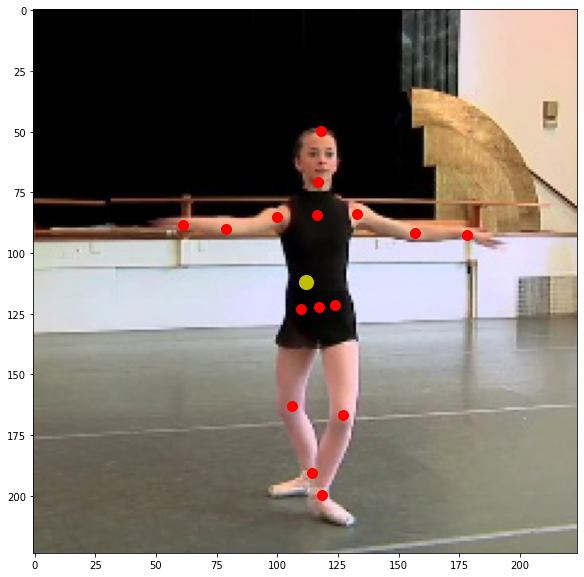

In [4]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.scatter(joints_X*width, joints_Y*height, color='r', s=100) # joints
plt.scatter(center[0]*width, center[1]*width, color='y', s=200) # center
plt.show()